#  Optical nerve across-species comparison

## Setup

### Import libraries:

In [3]:
## Set the right working directory:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import pandas as pd
import numpy as np
# import scipy as sc
# import seaborn as sns

# from math import pi

import matplotlib.pyplot as plt
from matplotlib import gridspec
#from matplotlib.image import NonUniformImage
#import matplotlib.image as mpimg
%matplotlib inline
# from skimage import io
# from skimage import measure
# from skimage import color
# from PIL import Image
# from pathlib import Path
from read_roi import read_roi_file
# from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
# from shapely.validation import explain_validity, make_valid
from utils import *

from pickle import load

/home/jovyan/projects/cellcount
/home/jovyan/projects/cellcount


### Choose parameters:

In [22]:
## Select which comparison accross species to plot:

# comparisons = [
#     ('Hr21', 'Hr11'),
#     ('Hr21', 'Cj22'),
#     ('Hr21', 'Aa14'),
#     ('Hr21', 'Du26'),
#     ('Hr21', 'Mc12'),
#     ('Hr21', 'Ft10'),
#     ('Fp23', 'Ft10'),
# ]

comparisons = [('Fp23', 'Ft10')]

save_intermediary_data = False
save_final_data = False

### Define paths:

In [4]:
path2kdrive = "/home/jovyan/kDrive"
path2rawimages = os.path.join(path2kdrive, "cellcount/data/BVSA-Histology-Epoxy")
path2plots = os.path.join(path2kdrive, 'cellcount/data/project_Aa_Hr_Fovea/plots')

### Define environment variables:

In [5]:
SPECIES_NAMES = {
    'Hr11': 'Barn Swallow (Hr11)',
    'Hr21': 'Barn Swallow (Hr21)',
    'Cj22': 'Japanese Quail (Cj22)',
    'Aa14': 'Common Swift (Aa14)',
    'Du26': 'House Martin (Du26)',
    'Du25': 'House Martin (Du25)',
    'Mc12': 'Grey Wagtail (Mc12)',
    'Ft10': 'Common Kestrel (Ft10)',
    'Fp23': 'Peregrine Falcon (Fp23)'
}
PX_RATIOS = {
    'Hr11': 1032.15/10422,
    'Hr21': 1120.39/11313,
    'Cj22': 1671.23/16875,
    'Aa14': 1228.76/18684,
    'Du26': 847.35/8556,
    'Du25': 1026.80/10368,
    'Mc12': 1112.37/11232,
    'Fp23': 2510.86/25353,
    'Ft10': 1949.32/19683,
    'Fp23': 2510.86/25353
}
SPECIES_COLORS = {
    'Hr11': "#1E72FA",
    'Hr21': "#1E72FA",
    'Aa14': "#E01EFA",
    'Du25': "#0145B3",
    'Du26': "#0145B3",
    'Ft10': "#1ED9FA",
    'Fp23': "#11A0AA",
    #'Mm04': "#B87B2B",
    'Mc12': "#975408",
    #'An01': "#E47900",
    'Cj22': "#37FF0F",
    'all':  "#000000"
}
# List of all available species:
all_species = list(SPECIES_NAMES.keys())

## Import and prepare data

In [6]:
## import all cellmarks in a dictionnary:
# cellmarks_dict is directly used for histograms comparing the size distribution of axons accross 2 species
cellmarks_dict = {}
for species in all_species:
    print(f"importing cellmarks for {species}...")
    pickle_filename_cm = f"pickled_data/cellmarks_{species}.pickle"
    with open(pickle_filename_cm, 'rb') as f:
        cellmarks_dict[species] = load(f)

importing cellmarks for Hr11...
importing cellmarks for Hr21...
importing cellmarks for Cj22...
importing cellmarks for Aa14...
importing cellmarks for Du26...
importing cellmarks for Du25...
importing cellmarks for Mc12...
importing cellmarks for Ft10...
importing cellmarks for Fp23...


In [15]:
# takes about 5 min:
df_all_species = get_axon_metrics(cellmarks_dict, ratios_dict=PX_RATIOS)

Hr11
Hr21
Cj22
Aa14
Du26
Du25
Mc12
Ft10
Fp23


In [16]:
df_all_species

,x,y,area,species
0,771.361306,4404.217780,0.111616,Hr11
1,779.000000,4410.000000,0.135155,Hr11
2,796.671231,4420.014532,0.741294,Hr11
3,803.515273,4444.930635,0.513747,Hr11
4,827.920836,4436.434735,0.282276,Hr11
...,...,...,...,...
1257768,22700.146432,16204.301206,0.197928,Fp23
1257769,22702.989384,16092.181529,0.215583,Fp23
1257770,22705.839555,16267.450884,0.099847,Fp23
1257771,22708.719754,16176.326759,0.417728,Fp23


#### Define thresholds and count axons:

In [17]:
# N.B. Minimum diameter detectable at the confocal is around 0.3-0.4 microns, thus the threshold for area is around 0.1 microns^2:
print(area_from_diameter(0.3), area_from_diameter(0.4))

min_area_thr = 0.1
small_area_thr = 0.5
big_area_thr = 5
huge_area_thr = 10

0.07068583470577035 0.12566370614359174


In [18]:
df_all_species_cut = df_all_species[df_all_species['area'] > min_area_thr]
df_all_species_small = df_all_species[(df_all_species['area'] > min_area_thr) & (df_all_species['area'] < small_area_thr)]
df_all_species_big_and_huge = df_all_species[df_all_species['area'] > big_area_thr] 
df_all_species_big = df_all_species[(df_all_species['area'] > big_area_thr) & (df_all_species['area'] < huge_area_thr)]
df_all_species_huge = df_all_species[df_all_species['area'] > huge_area_thr]

## thresholds for large axons are not the same for all species (used for the spatial map of large axons):
# big_area_thr = {'Hr11': 10, 'Hr21': 10, 'Cj22': 5, 'Aa14': 5, 'Du26': 5, 'Mc12': 5, 'Ft10': 5}
# df_all_species_big = df_all_species[df_all_species.apply(lambda x: x.area > big_area_thr[x.species], axis=1)]

In [19]:
grouped_by = df_all_species.groupby('species')
grouped_by_cut = df_all_species_cut.groupby('species')
grouped_by_small = df_all_species_small.groupby('species')
grouped_by_big = df_all_species_big.groupby('species')
grouped_by_huge = df_all_species_huge.groupby('species')
grouped_by_big_and_huge = df_all_species_big_and_huge.groupby('species')
# count number of axons
df_summary_all = grouped_by.count()
df_summary_cut = grouped_by_cut.count()
df_summary_small = grouped_by_small.count()
df_summary_big = grouped_by_big.count()
df_summary_huge = grouped_by_huge.count()
df_summary_big_and_huge = grouped_by_big_and_huge.count()

In [23]:
df_summary = pd.DataFrame({
#    'total_nb': df_summary_all['area'],
    'total_cut': df_summary_cut['area'],
    'total_small': df_summary_small['area'],
    'total_big': df_summary_big['area'],
    'total_huge': df_summary_huge['area'],
    'total_big_and_huge': df_summary_big_and_huge['area'],
})
# df_summary.rename(columns={'area': 'total_nb'}, inplace=True)
# df_summary.drop(columns=['x', 'y'], inplace=True)
df_summary['percentage_of_big'] = df_summary.apply(lambda x: x.total_big / x.total_cut * 100, axis=1)
df_summary['percentage_of_huge'] = df_summary.apply(lambda x: x.total_huge / x.total_cut * 100, axis=1)
df_summary['percentage_of_big_and_huge'] = df_summary.apply(lambda x: x.total_big_and_huge / x.total_cut * 100, axis=1)
## rearrange the bars according to custom species order:
species_order = ['Hr21', 'Hr11', 'Aa14', 'Du26', 'Du25', 'Mc12', 'Ft10', 'Cj22']
df_summary = df_summary.reindex(species_order)
print(df_summary.index)
df_summary

Index(['Hr21', 'Hr11', 'Aa14', 'Du26', 'Du25', 'Mc12', 'Ft10', 'Cj22'], dtype='object', name='species')


,total_cut,total_small,total_big,total_huge,total_big_and_huge,percentage_of_big,percentage_of_huge,percentage_of_big_and_huge
species,,,,,,,,
Hr21,173661,102160,1818,1020,2838,1.046867,0.587351,1.634218
Hr11,230249,144295,1685,266,1951,0.731816,0.115527,0.847344
Aa14,239573,126680,1352,74,1426,0.564337,0.030888,0.595226
Du26,147992,101871,770,59,829,0.520298,0.039867,0.560165
Du25,209364,142810,960,106,1066,0.458532,0.050630,0.509161
Mc12,179879,84483,2923,232,3155,1.624981,0.128976,1.753957
Ft10,621671,308545,11461,1864,13325,1.843580,0.299837,2.143417
Cj22,695374,502666,2255,264,2519,0.324286,0.037965,0.362251


In [24]:
if save_intermediary_data:
    # Save to CSV file
    csv_filename = os.path.join(path2plots, 'axon_numbers_statistics.csv')
    df_summary[['total_cut', 'total_small', 'total_big', 'total_huge', 'total_big_and_huge']].to_csv(csv_filename, index=True)

## Plot data

### Histograms across two or more species

In [10]:
# from utils.py
def axons_sizes_distribution(areas_dict, area_thr, species_names=None, path2save=None, stacked=False):
    '''
    - 
    '''
    
    species_list, areas_list = zip(*areas_dict.items())
    if len(areas_list) > 1:

        if species_list == ('Hr21', 'Cj22'):
            COLORS = ['#629DFB', '#7EE67E']
            SKIP_TEXT_SUMMARY_HR21 = True
        elif species_list == ('Hr21', 'Hr11'):
            COLORS = ['#629DFB', '#A6C7FD']
            SKIP_TEXT_SUMMARY_HR21 = False
        elif species_list == ('Hr21', 'Aa14'):
            COLORS = ['#629DFB', '#F007F0']
            SKIP_TEXT_SUMMARY_HR21 = True
        elif species_list == ('Hr21', 'Du26'):
            COLORS = ['#629DFB', '#1B24E0']
            SKIP_TEXT_SUMMARY_HR21 = True
        elif species_list == ('Hr21', 'Mc12'):
            COLORS = ['#629DFB', '#B81800']
            SKIP_TEXT_SUMMARY_HR21 = True           
        elif species_list == ('Hr21', 'Ft10'):
            COLORS = ['#629DFB', '#32B8ED']
            SKIP_TEXT_SUMMARY_HR21 = True
        elif species_list == ('Fp23', 'Ft10'):
            #COLORS = ["#81FFF6", '#32B8ED']
            COLORS = [SPECIES_COLORS['Fp23'], SPECIES_COLORS['Ft10']] 
            SKIP_TEXT_SUMMARY_HR21 = True
        # elif species_list == ('Aa14', 'Cj22'):
        #     COLORS = ['#00CC00', '#EC8600']
        # elif species_list == ('Hr21', 'Aa14', 'Du26'):
        #     COLORS = ['#629DFB', '#00CC00', '#1B24E0']
        # elif species_list == ('Hr21', 'Mc12', 'Cj22'):
        #     COLORS = ['#629DFB', '#00CC00', '#EC8600']            

        if stacked:
            fig, ax = plt.subplots(figsize=(15, 7))
            output_hist = ax.hist(areas_list, np.arange(0, 40, 0.5), log=True, density=False, histtype='bar', rwidth=1, color=COLORS)

            for id, areas in enumerate(areas_list):
                percent_gt_thr = round(len([True for i in areas if i > area_thr]) / len(areas) * 100) 
                textstr = '\n'.join((
                f'{species_names[species_list[id]]}: \n',
                f'total number of axons: {len(areas)}',
                f'median area of an axon: {np.median(areas): .2f} $\mu$m$^2$',
                f'proportion of axons $\geq {area_thr} \ \mu$m$^2$: {percent_gt_thr:.0f} %'
                ))
                if len(areas_list) == 2:
                    text_fontsize = 16
                    hspace_btw_textboxes = 0.35
                    textboxes_left_padding = 0.25
                else:
                    text_fontsize = 12
                    hspace_btw_textboxes = 0.3
                    textboxes_left_padding = 0.14

                if species_list[id] == 'Hr21' and SKIP_TEXT_SUMMARY_HR21:
                    pass
                else:
                    ax.text(
                        textboxes_left_padding + id*hspace_btw_textboxes,
                        0.95,
                        textstr,
                        transform=ax.transAxes,
                        fontsize=text_fontsize,
                        verticalalignment='top',
                        horizontalalignment='left',
                        color=COLORS[id]
                    )

            ax.set_ylabel('counts', fontsize=16)
            ax.set_xlabel(r'axon area [$\mu$m$^2$]', fontsize=16)
            ax.set_ylim(ymax=1e6)

            # change the fontsize:
            ax.tick_params(axis='x', labelsize=14)
            ax.tick_params(axis='y', labelsize=14)
        else:
            fig, axs = plt.subplots(nrows=1, ncols=len(areas_list), figsize=(15, 5))
            output_hist = {}
            for idx, areas in enumerate(areas_list):                
                percent_gt_thr = round(len([True for i in areas if i > area_thr]) / len(areas) * 100) # ratio of cells larger than 100 microns
                output_hist[species_list[idx]] = axs[idx].hist(areas, np.arange(0, round(np.max(areas))+2, 0.5), log=True, density=False, edgecolor='black')
                axs[idx].set_ylabel('counts')
                axs[idx].set_xlabel(r'axon area [$\mu$m$^2$]')
                textstr = '\n'.join((
                f'total number of axons: {len(areas)}',
                f'median area of an axon: {np.median(areas):.2f} $\mu$m$^2$',
                f'proportion of axons $\geq {area_thr} \ \mu$m$^2$: {percent_gt_thr:.0f} %'
                ))
                axs[idx].text(0.45, 0.95, textstr, transform=axs[idx].transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
                axs[idx].set_title(species_list[idx])
                # axs[idx].set_ylim(ymin=0, ymax=300)
                # axs[idx].set_xlim(xmin=0, xmax=6)

    else:
        fig, ax = plt.subplots(figsize=(10, 10))
        areas = areas_list[0]
        percent_gt_thr = round(len([True for i in areas if i > area_thr]) / len(areas) * 100) 
        print(f"Largest axon is : {np.max(areas)} $\mu$m$^2$")
        output_hist = ax.hist(areas, np.arange(0, round(np.max(areas))+2, 0.5), log=True, density=False, edgecolor='black')
        ax.set_ylabel('counts')
        ax.set_xlabel(r'axon area [$\mu$m$^2$]')
        textstr = '\n'.join((
        f'total number of axons: {len(areas)}',
        f'median area of an axon: {np.median(areas): .2f} $\mu$m$^2$',
        f'proportion of axons $\geq {area_thr} \ \mu$m$^2$: {percent_gt_thr:.0f} %'
        ))
        ax.text(0.45, 0.95, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')
        ax.set_title(species_list[0])
        #ax.set_ylim(ymin=0, ymax=300)
        #ax.set_xlim(xmin=0, xmax=6)

    if path2save is not None:
        fig.savefig(path2save, facecolor='white')

    return output_hist

dict_keys(['Fp23', 'Ft10'])
Fp23
Ft10


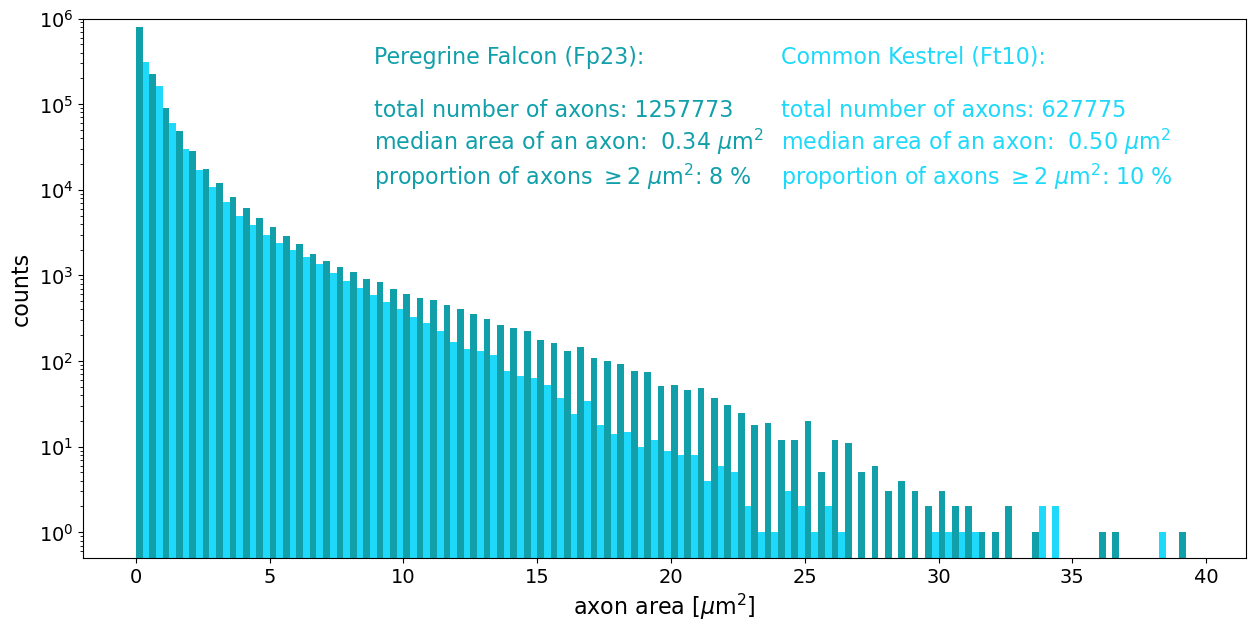

In [13]:
for species_list in comparisons:
    if save_final_data:
        path2save = os.path.join(path2plots, f"axon_sizes_distribution_{species_list[0]}_vs_{species_list[1]}.png")
        #path2save=os.path.join(path2plots, f"axon_sizes_distribution_{species_list[0]}_vs_{species_list[1]}_vs_{species_list[2]}.png")
    else:
        path2save = None

    cellmarks_comparison = {k:cellmarks_dict[k] for k in species_list}
    print(cellmarks_comparison.keys())
    area_dict = get_axon_area(cellmarks_comparison, ratios_dict=PX_RATIOS)
    h = axons_sizes_distribution(
        area_dict,
        area_thr=2,
        species_names=SPECIES_NAMES,
        stacked=True,
        path2save=path2save
    )

### Plot summary statistics accross all species

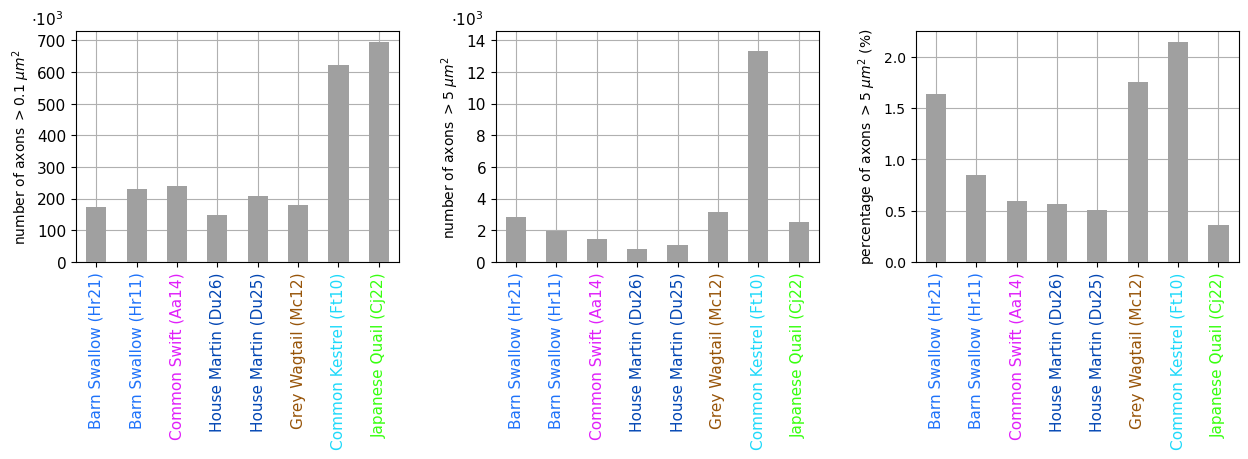

In [25]:
X = list(range(len(df_summary)))

fig = plt.figure(figsize=(15, 3))
spec = gridspec.GridSpec(ncols=3, nrows=1, wspace=0.3)

# first subplot:
ax0 = fig.add_subplot(spec[0])
ax0 = df_summary['total_cut'].plot.bar(stacked=False, zorder=3, color='#A0A0A0', xlabel='')
ax0.set_xticks(np.arange(0, len(df_summary.index), 1))
ax0.set_xticklabels([SPECIES_NAMES[s] for s in species_order], fontsize=11)
# Color the y-axis tick labels:
for tick_label, species in zip(ax0.get_xticklabels(), species_order):
    tick_label.set_color(SPECIES_COLORS[species])

ax0_yticks_locations = np.arange(0, 8e5, 1e5)
ax0.set_yticks(ax0_yticks_locations)
ax0.set_yticklabels([int(t * 1e-3) for t in ax0_yticks_locations], fontsize=11)
plt.gcf().text(0.095, 0.9, "$\cdot 10^3$", fontsize=11)
ax0.set_ylabel(f"number of axons $>${min_area_thr} $\mu m^2$", fontsize=10)
plt.grid()

# second subplot:
ax1 = fig.add_subplot(spec[1])
ax1 = df_summary['total_big_and_huge'].plot.bar(stacked=False, zorder=3, color='#A0A0A0', xlabel='')
ax1.set_xticks(np.arange(0, len(df_summary.index), 1))
ax1.set_xticklabels([SPECIES_NAMES[s] for s in species_order], fontsize=11)
# Color the y-axis tick labels:
for tick_label, species in zip(ax1.get_xticklabels(), species_order):
    tick_label.set_color(SPECIES_COLORS[species])

ax1.set_ylim(0, 14e3+600)
ax1_yticks_locations = np.arange(0, 16e3, 2e3)
ax1.set_yticks(ax1_yticks_locations)
ax1.set_yticklabels([int(t * 1e-3) for t in ax1_yticks_locations], fontsize=11)
plt.gcf().text(0.375, 0.9, "$\cdot 10^3$", fontsize=11)
ax1.set_ylabel(f"number of axons $>${big_area_thr} $\mu m^2$", fontsize=10)
plt.grid()

# third subplot:
ax2 = fig.add_subplot(spec[2])
ax2 = df_summary['percentage_of_big_and_huge'].plot.bar(stacked=False, zorder=3, color='#A0A0A0', xlabel='')
ax2.set_xticks(np.arange(0, len(df_summary.index), 1))
ax2.set_xticklabels([SPECIES_NAMES[s] for s in species_order], fontsize=11)
# Color the y-axis tick labels:
for tick_label, species in zip(ax2.get_xticklabels(), species_order):
    tick_label.set_color(SPECIES_COLORS[species])
ax2.set_ylabel(f"percentage of axons $>${big_area_thr} $\mu m^2$ (%)", fontsize=10)
plt.grid()

if save_final_data:
    path2save = os.path.join(path2plots, 'large_axons_ratio_accross_species_comparison.png')
    print(f"Saving plot in following location: {path2save}")
    fig.savefig(path2save, facecolor='white', bbox_inches = 'tight')

### Spatial plot of large axons

In [ ]:
# species = 'Fp23'

# #path2borderrois = os.path.join(path2rawimages, species, 'ON1_1', f"{species}_ON1_border.roi") # Ft10
# path2borderrois = os.path.join(path2rawimages, species, 'ON2', f"{species}_ON2_border.roi") # Fp23
# rois = read_roi_file(path2borderrois)
# border_x = rois[f"{species}_ON2_border"]['x']
# border_y = rois[f"{species}_ON2_border"]['y']
# polyborder = contour2polygon(np.column_stack((rois[f"{species}_ON2_border"]['x'], rois[f"{species}_ON2_border"]['y'])))
# polyborder.area * PX_RATIOS[species]**2 * 1e-6 # area in mm^2

3.8780373012667204

#### TESTING: spatial plot for a single species:

In [26]:
species = 'Du25'
subdf = df_all_species_big[df_all_species_big['species'] == species]
#subdf = df_all_species[df_all_species['species'] == 'Hr11']

In [27]:
# Import the border of the given ON:
#path2borderrois = os.path.join(path2rawimages, species, 'ON1_1', f"{species}_ON1_border.roi")
path2borderrois = os.path.join(path2rawimages, species, 'Du25_ON2', f"{species}_ON1_border.roi")
rois = read_roi_file(path2borderrois)
border_x = rois[f"{species}_ON1_border"]['x']
border_y = rois[f"{species}_ON1_border"]['y']
#polyborder = contour2polygon(np.column_stack((rois[f"{species}_ON1_border"]['x'], rois[f"{species}_ON1_border"]['y']))) # not used

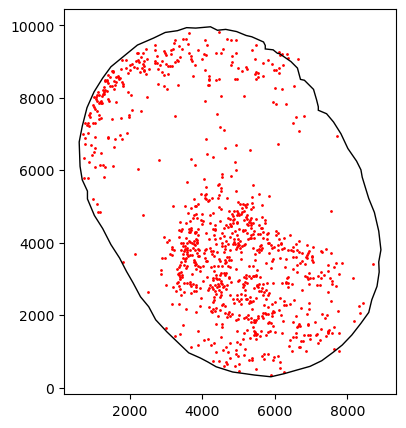

In [28]:
fig = plt.figure(figsize=(5, 5))
spec = gridspec.GridSpec(ncols=1, nrows=1, wspace=0.3)
ax = fig.add_subplot(spec[0])
plt.scatter(subdf['x'], subdf['y'], s=1, color='red')
plt.fill(border_y, border_x, fill=False)
ax.set_aspect('equal')

#### All species:

In [36]:
X_AXIS_LIMITS = { # in pixels
    'Hr11': [0, 1.2e4],
    'Hr21': [0, 9e3],
    'Mc12': [0, 1.5e4],
    'Du26': [0, 8e3],
    'Du25': [0, 9e3],
    'Aa14': [0, 1.6e4],
    'Cj22': [0, 1.6e4],
    'Ft10': [0, 2.2e4],
    'Fp23': [0, 2.5e4],
}

X_LABEL_STEP = { # in microns
    'Hr11': 2.5e2,
    'Hr21': 2.5e2,
    'Mc12': 5e2,
    'Du26': 2.5e2,
    'Du25': 2.5e2,
    'Aa14': 2.5e2,
    'Cj22': 5e2,
    'Ft10': 5e2,
    'Fp23': 5e2,
}

Y_AXIS_LIMITS = { # in pixels
    'Hr11': [0, 1e4],
    'Hr21': [0, 1.2e4],
    'Mc12': [0, 1.2e4],
    'Du26': [0, 9e3],
    'Du25': [0, 1e4],
    'Aa14': [0, 1.8e4],
    'Cj22': [0, 1.8e4],
    'Ft10': [0, 2e4],
    'Fp23': [0, 2.5e4],
}

Y_LABEL_STEP = { # in microns
    'Hr11': 2.5e2,
    'Hr21': 2.5e2,
    'Mc12': 5e2,
    'Du26': 2.5e2,
    'Du25': 2.5e2,
    'Aa14': 2.5e2,
    'Cj22': 5e2,
    'Ft10': 5e2,
    'Fp23': 5e2,
}

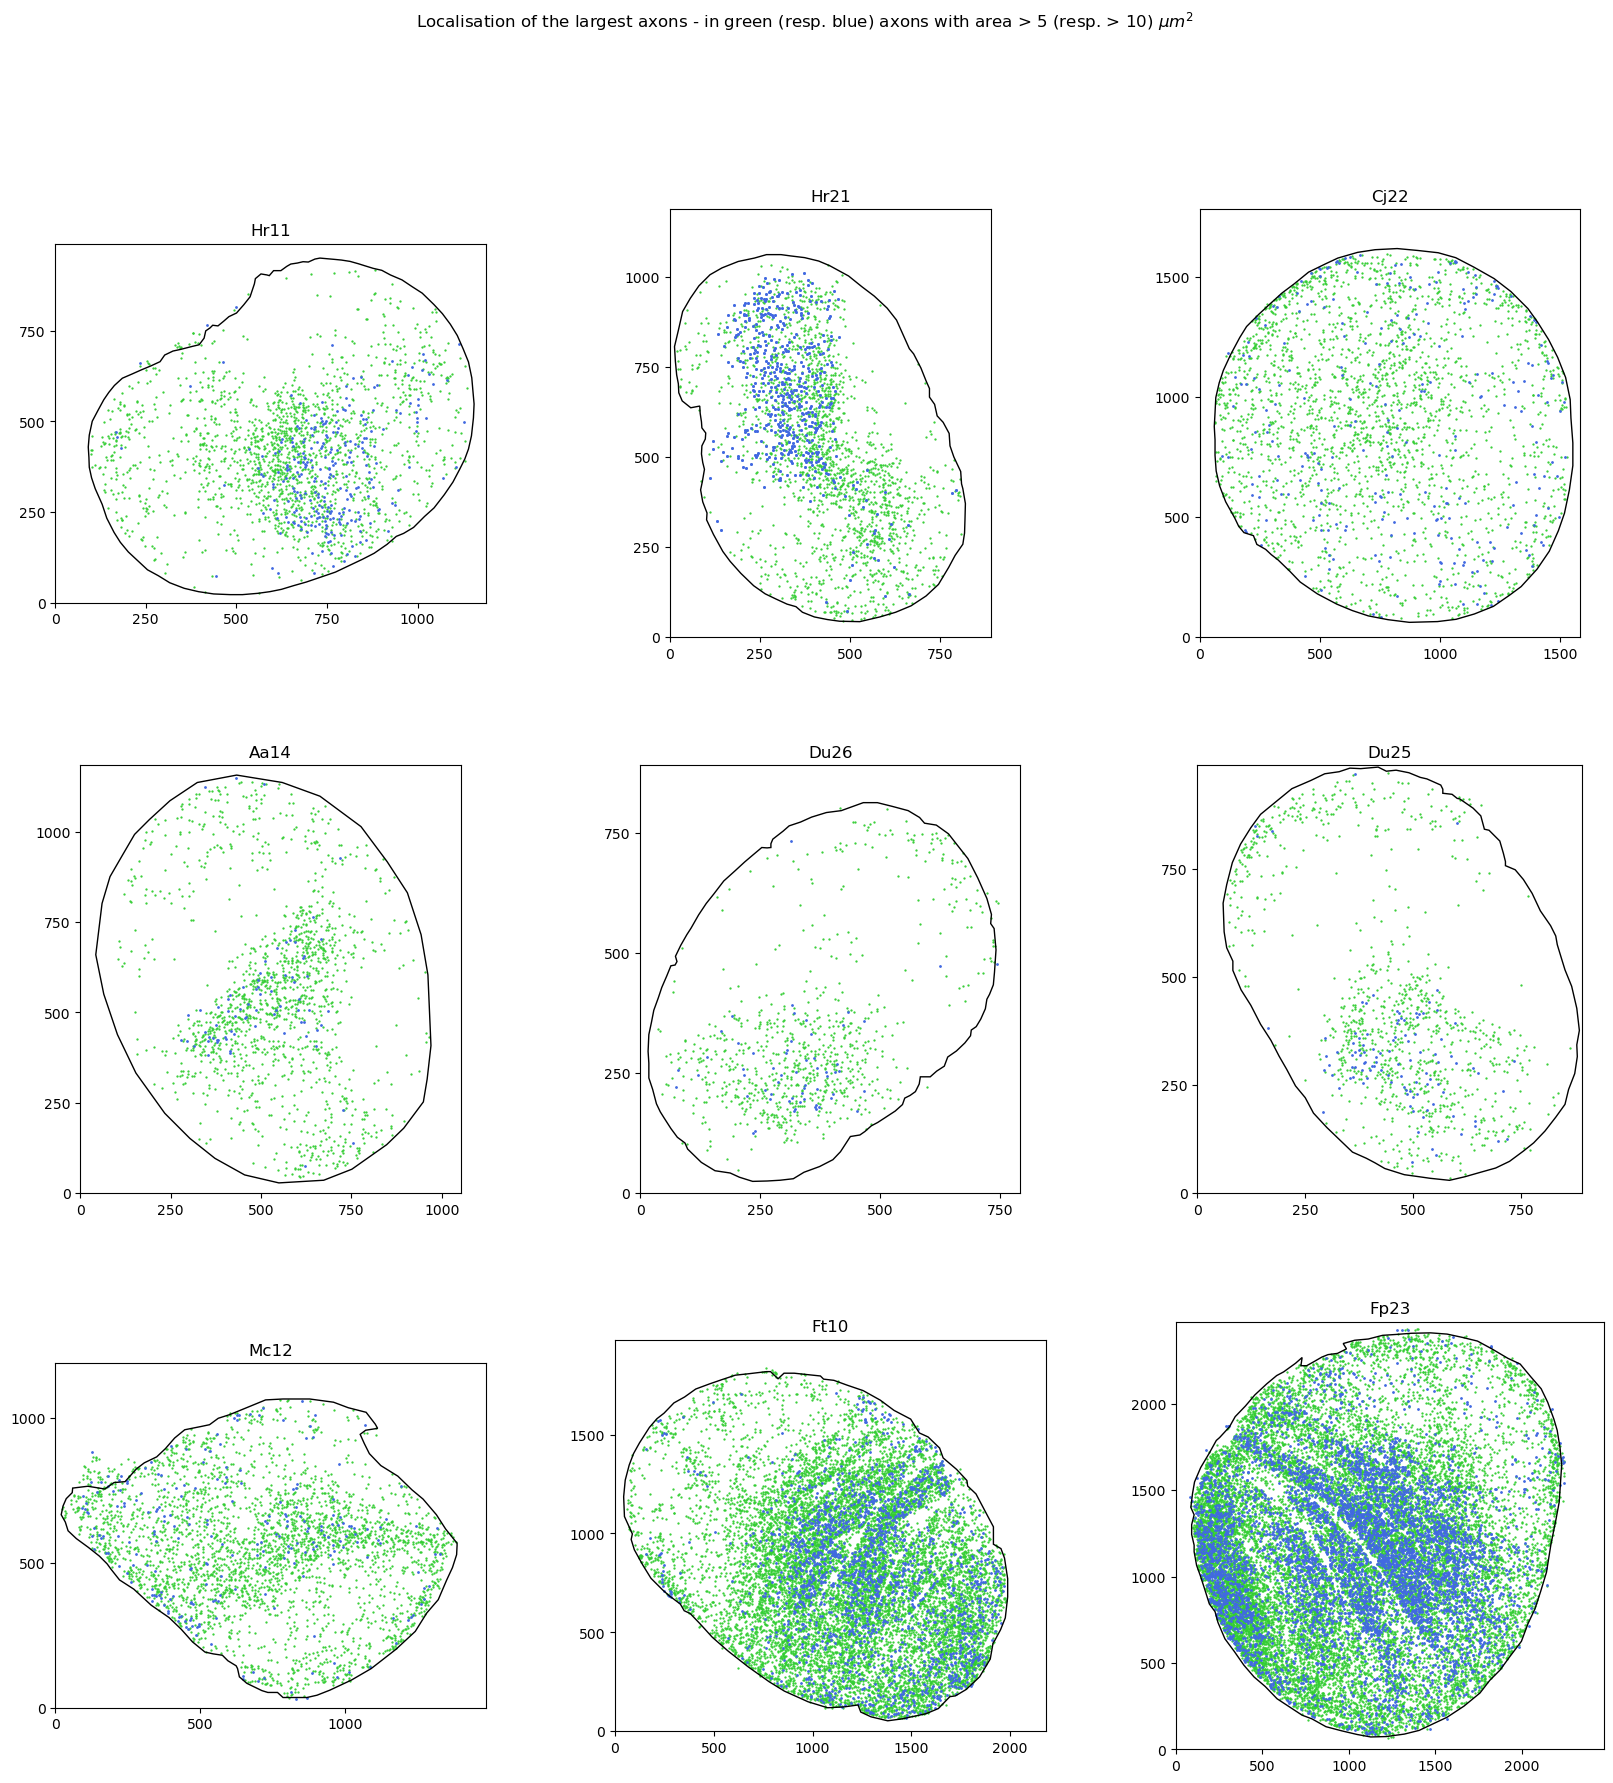

In [37]:
fig = plt.figure(figsize=(20, 20))
spec = gridspec.GridSpec(ncols=3, nrows=3, wspace=0.3, hspace=0.3)
## reorder for plotting below:
#all_species = ['Hr11', 'Hr21', 'Aa14', 'Du26', 'Ft10', 'Mc12', 'Cj22']
for idx, species in enumerate(all_species):
    
    if species == 'Du25':
        path2borderrois = os.path.join(path2rawimages, species, 'Du25_ON2', f"{species}_ON1_border.roi")
    elif species == 'Fp23':
        path2borderrois = os.path.join(path2rawimages, species, 'ON2', f"{species}_ON1_border.roi")
    else:
        path2borderrois = os.path.join(path2rawimages, species, 'ON1_1', f"{species}_ON1_border.roi")

    rois = read_roi_file(path2borderrois)
    border_x = rois[f"{species}_ON1_border"]['x']
    border_y = rois[f"{species}_ON1_border"]['y']

    subdf_big = df_all_species_big[df_all_species_big['species'] == species]
    subdf_huge = df_all_species_huge[df_all_species_huge['species'] == species]
    ax = fig.add_subplot(spec[idx])
    plt.scatter(subdf_big['x'], subdf_big['y'], s=0.4, color='limegreen', marker='o')
    plt.scatter(subdf_huge['x'], subdf_huge['y'], s=1, color='royalblue', marker='o')
    plt.fill(border_y, border_x, fill=False) # axon shape
    
    # define x-axis limits, ticks and labels:
    x_axis_limits = X_AXIS_LIMITS[species] # in pixels
    x_label_step = X_LABEL_STEP[species] # in microns
    x_ticks = np.arange(x_axis_limits[0], x_axis_limits[1], x_label_step/PX_RATIOS[species]) # ticks locations are in pixels
    x_labels = [t*x_label_step for t in range(len(x_ticks))] # ticks labels are in microns
    
    y_axis_limits = Y_AXIS_LIMITS[species] # in pixels
    y_label_step = Y_LABEL_STEP[species] # in microns
    y_ticks = np.arange(y_axis_limits[0], y_axis_limits[1], y_label_step/PX_RATIOS[species])
    y_labels = [t*y_label_step for t in range(len(y_ticks))] # ticks labels are in microns
    
    ax.set_xlim(x_axis_limits[0], x_axis_limits[1])
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([int(x) for x in x_labels])    
    
    ax.set_ylim(y_axis_limits[0], y_axis_limits[1])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([int(x) for x in y_labels])


    ax.set_aspect('equal')
    ax.set_title(f"{species}")


_ = fig.suptitle(f"Localisation of the largest axons - in green (resp. blue) axons with area > {big_area_thr} (resp. > {huge_area_thr})" + ' $\mu m^2$')

if save_final_data:
    path2save = os.path.join(path2plots, 'localisation_largest_axons_across_species.png')
    fig.savefig(path2save, facecolor='white')